# Customer Segmentation for Retail: Improving targeted Marketing Using Hierarchical Clustering

In [33]:
#Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [34]:
# Load Dataset

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.shape

(200, 5)

In [36]:
# Select Relevant Features (Annual Income & Spending Score are best for Visualization

X = df.iloc[:, [3,4]].values
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

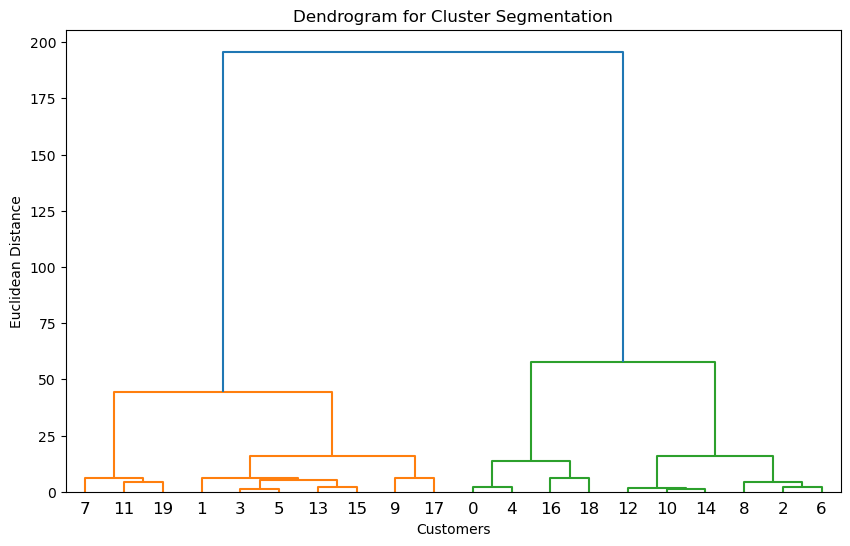

In [37]:
# Create Dendogram to find optimal clusters

plt.figure(figsize = (10,6))
dendrogram = sch.dendrogram(sch.linkage(X[:20], method ='ward'))

plt.title("Dendrogram for Cluster Segmentation")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [38]:
# Fit Agglomerative Hierarchical Clustering

hc = AgglomerativeClustering(n_clusters =5, metric = 'euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

In [39]:
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

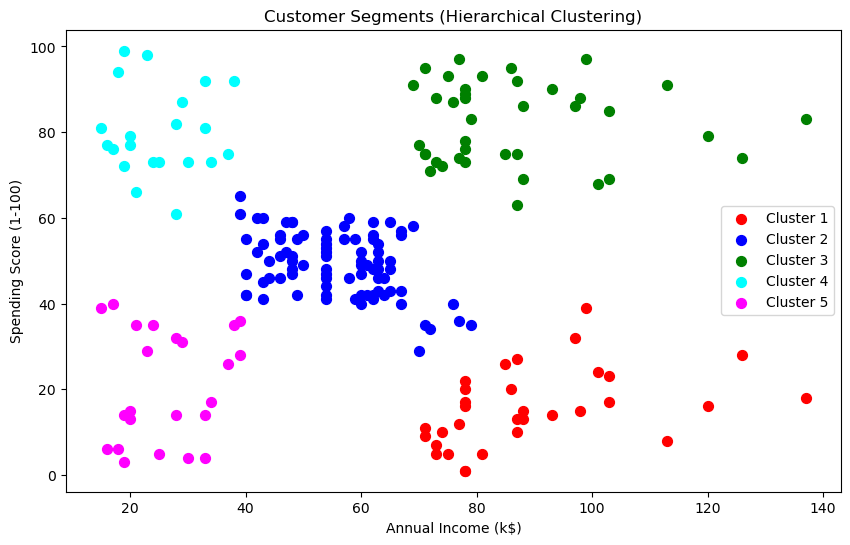

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=50, c='red', label='Cluster 1')

plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=50, c='blue', label='Cluster 2')

plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s=50, c='magenta', label='Cluster 5')

plt.title("Customer Segments (Hierarchical Clustering)")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [41]:
# Model evaluation : silhouette_score

from sklearn.metrics import silhouette_score
# Select features for silhouette calculation (without CustomerID or Cluster label)

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Compute silhouette score
score = silhouette_score(X, y_hc)
print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.553


In [42]:
# Observation
# We can see clustering is very much upto and clear.

# Silhouette Score is 0.55 which is quite acceptable